In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    url,
    names=columns,
    na_values="?",
    skipinitialspace=True
)


display(df.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


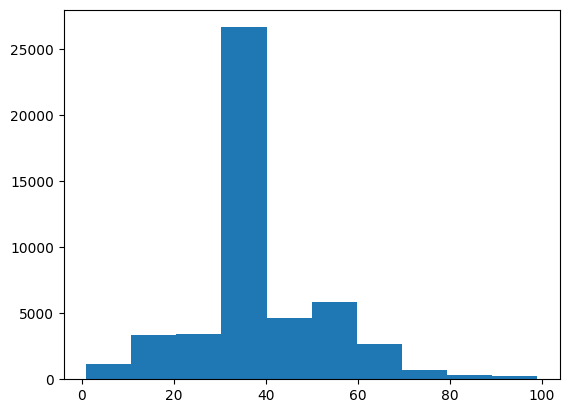

In [120]:
plt.hist(df["hours_per_week"])
plt.show()

hours_per_week
40    22803
50     4246
45     2717
60     2177
35     1937
20     1862
30     1700
55     1051
25      958
48      770
Name: count, dtype: int64

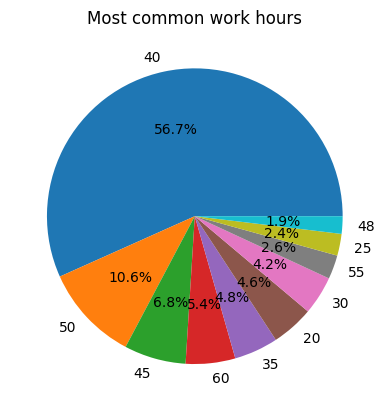

In [131]:
hours_couts = df["hours_per_week"].value_counts().head(10)

display(hours_couts)

plt.pie(
    hours_couts,
    labels=hours_couts.index,
    autopct="%1.1f%%"
)

plt.title("Most common work hours")

plt.show()

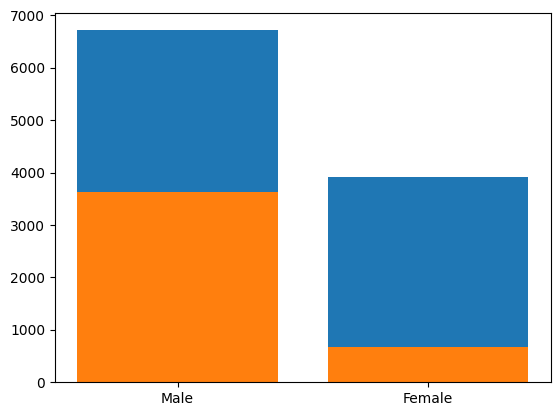

In [185]:
df_clean = df[df["workclass"] != "Private"]

low = df_clean[df_clean["income"] == "<=50K"]
high = df_clean[df_clean["income"] == ">50K"]

low_counts = low["sex"].value_counts().head()
high_counts = high["sex"].value_counts().head()

plt.bar(
    low_counts.index,
    low_counts.values
)


plt.bar(
    high_counts.index,
    high_counts.values
)

plt.show()

In [177]:
low = df[df["income"] == "<=50K"]
high = df[df["income"] == ">50K"]

low_counts = low["workclass"].value_counts().head()
high_counts = high["workclass"].value_counts().head()

plt.figure(1)

plt.pie(
    high_counts,
    labels=high_counts.index
)

plt.show()

plt.figure(2)

plt.pie(
    low_counts,
    labels=low_counts.index
)

plt.show()

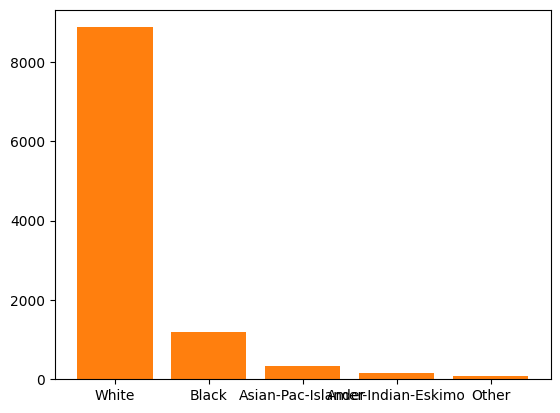

In [184]:
df_clean = df[df["workclass"] != "Private"]

low = df_clean[df_clean["income"] == "<=50K"]
high = df_clean[df_clean["income"] == ">50K"]

low_counts = low["race"].value_counts()
high_counts = high["race"].value_counts()

plt.bar(low_counts.index, low_counts.values)
plt.bar(high_counts.index, low_counts.values)
plt.show()

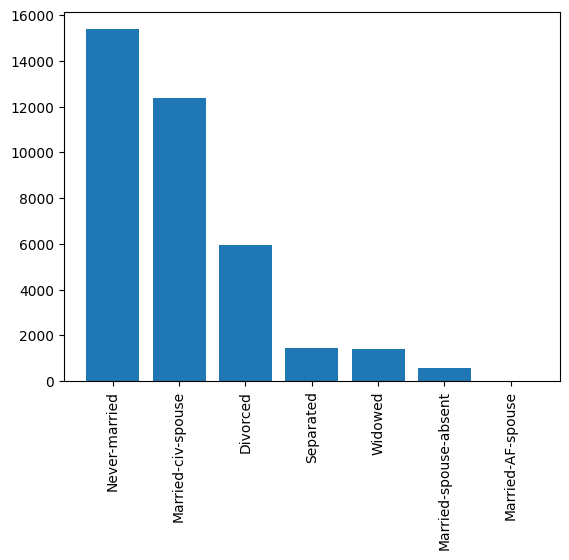

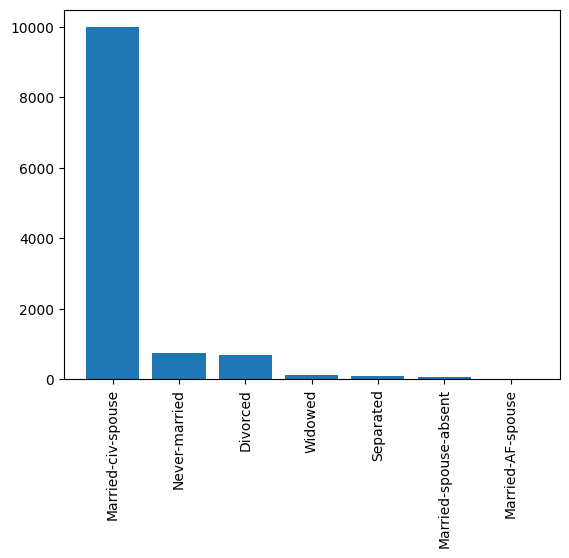

In [2]:
low = df[df["income"] == "<=50K"]
high = df[df["income"] == ">50K"]

low_counts = low["marital_status"].value_counts()
high_counts = high["marital_status"].value_counts()

plt.figure(1)
plt.bar(low_counts.index, low_counts.values)
plt.xticks(rotation=90)

plt.figure(2)
plt.bar(high_counts.index, high_counts.values)
plt.xticks(rotation=90)

plt.show()

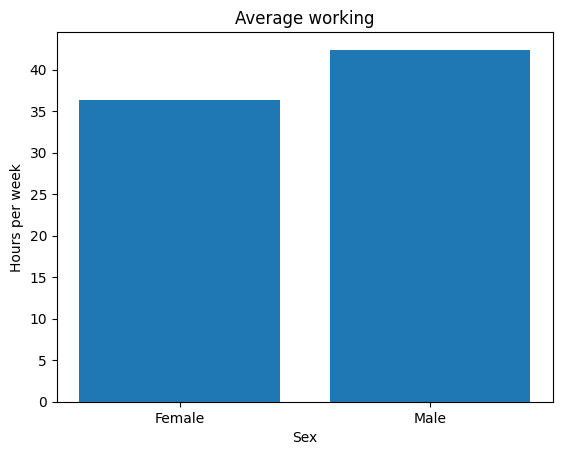

In [5]:
#Гипотеза: у мужчин больше рабочих часов, чем у женщин
import matplotlib.pyplot as plt

gender_hours = df.groupby("sex")["hours_per_week"].mean()

plt.bar(gender_hours.index, gender_hours.values)
plt.title("Average working")
plt.xlabel("Sex")
plt.ylabel("Hours per week")
plt.show()

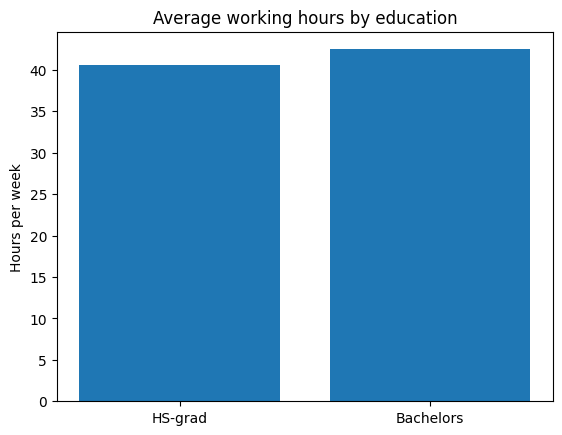

In [12]:
import pandas as pd

low_edu = df[df["education"] == "HS-grad"]
high_edu = df[df["education"] == "Bachelors"]

low_avg = low_edu["hours_per_week"].mean()
high_avg = high_edu["hours_per_week"].mean()

labels = ["HS-grad", "Bachelors"]
values = [low_avg, high_avg]

plt.bar(labels, values)
plt.title("Average working hours by education")
plt.ylabel("Hours per week")
plt.show()



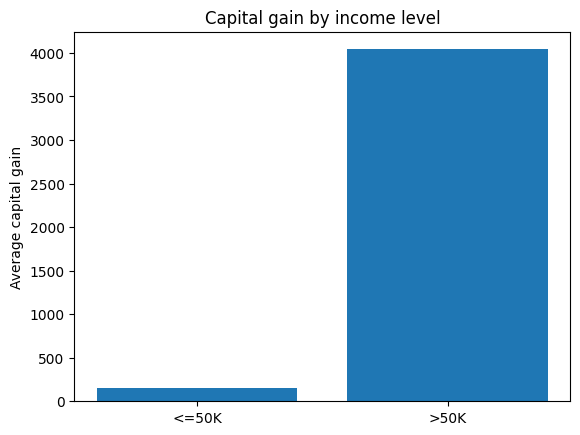

In [19]:
#Люди с высоким доходом чаще имеют капитал-доход

import matplotlib.pyplot as plt
import pandas as pd

low_income = df[df["income"] == "<=50K"]
high_income = df[df["income"] == ">50K"]

low_avg = low_income["capital_gain"].mean()
high_avg = high_income["capital_gain"].mean()

plt.bar(["<=50K", ">50K"], [low_avg, high_avg])
plt.title("Capital gain by income level")
plt.ylabel("Average capital gain")
plt.show()